In [27]:
# LangGraph에서 상태 그래프를 만들기 위한 클래스와
# 그래프의 시작/끝을 나타내는 상수를 가져옵니다.
from langgraph.graph import StateGraph, START, END

# 파이썬에서 "딕셔너리 형태의 타입"을 정의할 수 있게 해주는 도구입니다.
from typing_extensions import TypedDict

In [28]:
# 그래프에서 오고 가는 상태(state)의 모양을 정의합니다.
# - hello: 문자열 값
# - a: True/False 를 담는 불리언 값
class State(TypedDict):
  hello: str
  a: bool

# 위에서 정의한 State 타입을 사용하는 상태 그래프를 만듭니다.
# 이 graph_builder 에 노드와 간선(연결 관계)을 차례대로 등록합니다.
graph_builder = StateGraph(State)

In [29]:
# 각 노드는 "state" 를 입력으로 받아서,
# (필요하다면) 출력 state 를 바꿔서 돌려주는 함수입니다.

# 첫 번째 노드: node_one
# - 들어온 state 는 쓰지 않고, 항상 같은 값을 돌려줍니다.
# - "hello" 값을 "from node one." 으로 바꾸고,
#   "a" 값을 True 로 설정합니다.
def node_one(state: State) -> State:
  print("node_one")  # 실행 흐름을 보기 위한 출력
  return {
    "hello": "from node one.",
    "a": True
  }

# 두 번째 노드: node_two
# - "hello" 값을 "from noe two." 로 덮어씁니다.
# - "a" 값은 건드리지 않으므로 이전 값(True)이 유지됩니다.
def node_two(state: State) -> State:
  print("node_two")
  return {
    "hello": "from noe two."
  }

# 세 번째 노드: node_three
# - 최종적으로 "hello" 값을 "from node three." 로 바꿉니다.
def node_three(state: State) -> State:
  print("node_three")
  return {
    "hello": "from node three."
  }
  

In [30]:
# 그래프에 사용할 노드(함수)를 등록합니다.
# 첫 번째 인자: 노드 이름(문자열)
# 두 번째 인자: 실제로 실행될 파이썬 함수
graph_builder.add_node("node_one", node_one)
graph_builder.add_node("node_two", node_two)
graph_builder.add_node("node_three", node_three)

# 노드들 사이의 연결(edge)을 정의합니다.
# START -> node_one -> node_two -> node_three -> END
# 이런 순서로 노드들이 실행되게 됩니다.
graph_builder.add_edge(START, "node_one")
graph_builder.add_edge("node_one", "node_two")
graph_builder.add_edge("node_two", "node_three")
graph_builder.add_edge("node_three", END)


In [31]:
# 지금까지 정의한 노드와 연결 정보를 이용해서
# 실제로 실행 가능한 그래프 객체를 만듭니다.
graph = graph_builder.compile()

# graph.invoke(...) 를 호출하면 그래프를 "한 번 실행" 하는 것과 같습니다.
# - 초기 state 로 {"hello": "world"} 를 넣어 주고,
# - START -> node_one -> node_two -> node_three -> END 순서로
#   노드들이 차례대로 호출됩니다.
result = graph.invoke(
  {
    "hello": "world",
  }
)

node_one
node_two
node_three


In [32]:
result

{'hello': 'from node three.', 'a': True}

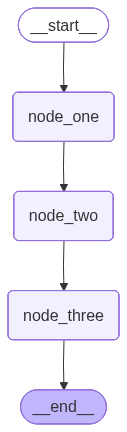

In [33]:
graph